In [1]:
import pandas as pd
import json
import numpy as np 
import re
import seaborn as sns
import matplotlib.pyplot as plt
import random
import os
from random import sample
%load_ext autoreload
%autoreload 2

In [2]:
# read parquet file here
dataDir = '/Users/wayne/Desktop/Cluster/H4Hhome/2BLAST/clinical_notes/HealthReportRecords/results_status_dates/processed/dataframes'
mergedNotesMaster = pd.read_parquet(f'{dataDir}/merged_processed_clinicalNotes.parquet.gzip', engine='pyarrow', use_nullable_dtypes = True)

/var/folders/xl/pdrtfmy950768yqxtqn387s80000gp/T/ipykernel_4463/385020756.py:3: FutureWarning: The argument 'use_nullable_dtypes' is deprecated and will be removed in a future version.Use dtype_backend='numpy_nullable' instead of use_nullable_dtype=True.
  mergedNotesMaster = pd.read_parquet(f'{dataDir}/merged_processed_clinicalNotes.parquet.gzip', engine='pyarrow', use_nullable_dtypes = True)


# Counts on status of job

## Entire time period

In [3]:
# look at paired counts of status
dfStatus = mergedNotesMaster.groupby(['Observations.StatusFromOrder', 'Observations.Observation.status']).size().reset_index(name='counts')
dfStatus['count_pct'] = dfStatus['counts']/dfStatus['counts'].sum()
dfStatus.sort_values( by='count_pct', ascending=False, inplace=True )
dfStatus

,Observations.StatusFromOrder,Observations.Observation.status,counts,count_pct
4,completed,dummy,930715,0.706548
5,completed,final,196164,0.148917
13,unknown,dummy,66514,0.050494
9,draft,preliminary,56011,0.042521
7,completed,unknown,32857,0.024943
11,dummy,unknown,18163,0.013788
3,completed,corrected,9050,0.006870
10,draft,unknown,5926,0.004499
6,completed,preliminary,1002,0.000761
14,unknown,unknown,449,0.000341


## Between Jan 1, 2008 and Feb 28, 2018

In [4]:
# restrict time period. check paired counts of status
mask =  ( mergedNotesMaster['visitDate'] >= '2008-1-01' ) & ( mergedNotesMaster['visitDate'] < '2018-03-01' )
dfStatusPreSpike = mergedNotesMaster.loc[mask].groupby(['Observations.StatusFromOrder', 'Observations.Observation.status']).size().reset_index(name='counts')
dfStatusPreSpike['count_pct'] = dfStatusPreSpike['counts']/dfStatusPreSpike['counts'].sum()
dfStatusPreSpike.sort_values( by='count_pct', ascending=False, inplace=True )
dfStatusPreSpike 

,Observations.StatusFromOrder,Observations.Observation.status,counts,count_pct
1,completed,dummy,836327,0.930582
9,unknown,dummy,58612,0.065218
2,completed,final,1813,0.002017
4,completed,unknown,916,0.001019
7,dummy,unknown,357,0.000397
5,draft,dummy,335,0.000373
0,completed,corrected,223,0.000248
10,unknown,unknown,113,0.000126
6,draft,preliminary,12,0.000013
3,completed,preliminary,4,0.000004


# Extract job ID from the note if possible

In [5]:
def extractJobNum( x ):
    """
    Extract job number from the note if possible. This is heuristic 
    and based on trial and error. It is not perfect and all-encompassing.

    Case 1: "job#" string is present
    Case 2: "dictated but not read" string is present

    x: A string representing the clinical note     
    """

    x = x.lower()

    if 'job#:' in x:
    
        # find the index of job#: 
        title_str = 'job#:'
        idx = x.find(title_str)
        title_str_nl = 'job#:\n'
        if x.find(title_str_nl) != -1:
            idx = x.find(title_str_nl)
            title_str = title_str_nl
        # filter to this substring only
        xJob = x[idx+len(title_str):]

        # find the first \n
        idxNL = xJob.find('\n')

        # extract job#
        jobID = str(xJob[:idxNL])
        # remove extra white spaces
        jobID = re.sub(' +', '', jobID)

        return jobID 
    
    elif 'dictated but not read' in x:
        
        jobID = helperExtractJobID_DictatedNotRead(x, 1)

        if jobID == None:
            return jobID
        elif any(chr.isalpha() for chr in jobID):
            jobID = helperExtractJobID_DictatedNotRead(x, 0)
        
        return jobID

def helperExtractJobID_DictatedNotRead(x, first):
    """
    Helper function to extract job number from note if 'dictated but
    not read' string is present.
    
    x: A string representing the clinical note
    first: Boolean indicating whether to search for the first (1) or
           last (0) occurrence of 'dictated but not read'
    """

    # find position index of dictated but not read
    strToSearch = 'dictated but not read'
    if first == 1:
        # first occurrence
        idx = x.find( strToSearch )
    else:
        # last occurrence
        idx = x.rfind( strToSearch )
    # filter to this substring only
    xJob = x[idx:]

    #xJob = xJob[idxNL+1:]
    xJob = xJob[len(strToSearch)+1:]

    # find transcribed by
    endIdx = xJob.find('transcribed by')

    if endIdx == -1:
        return None

    jobID = xJob[:endIdx]
    jobID = jobID.replace("\n","")
    jobID = re.sub(' +', '', jobID)

    # handle special cases
    jobID = jobID.replace("-re-dictation","")
    jobID = jobID.replace("jobid","")
    jobID = jobID.replace("statnote","")
    jobID = jobID.replace("stat","")
    jobID = jobID.replace("job#","")
    jobID = jobID.replace("redictation","")
    jobID = jobID.replace("-redictation","")
    jobID = jobID.replace("-","")

    if jobID == '' or not any(chr.isdigit() for chr in jobID):
        return None
    else:
        return jobID

In [6]:
# extract job id from text
mergedNotesMaster['job_id'] = mergedNotesMaster['clinical_notes'].apply( lambda x: extractJobNum(x) )
mergedNotesMaster['job_id']

0                  2909060
1                  2044448
2                  2909060
3                  3857476
4          4593529/2104768
                ...       
1317265            4190818
1317266            4519009
1317267            4519009
1317268            4353571
1317269            4195620
Name: job_id, Length: 1317270, dtype: object

In [7]:
# print statistics on notes with extractable job id
print( "Number of notes with non-null jobid: ", sum( mergedNotesMaster['job_id'].notnull() ) )
print( "Proportion of notes with non-null jobid: ", sum( mergedNotesMaster['job_id'].notnull() ) / mergedNotesMaster.shape[0] )

Number of notes with non-null jobid:  952060
Proportion of notes with non-null jobid:  0.7227523590456019


In [8]:
# what are the procedure names of the notes with extractable job id?
mergedNotesMaster.loc[ mergedNotesMaster['job_id'].notnull() ]['Observations.ProcName'].unique()

array(['Consultation Note', 'OR Procedure/Notes', 'Clinic Note', 'Letter',
       'Unscheduled Discharge Summary', 'Radiation Therapy Note',
       'History & Physical Note', 'Discharge Summary', 'Operative Note',
       'Communication Note'], dtype=object)

In [9]:
# what are the procedure names which don't have job id's at all?
uniqueProc = list( mergedNotesMaster['Observations.ProcName'].unique() )
print( [x for x in uniqueProc if x not in mergedNotesMaster.loc[ mergedNotesMaster['job_id'].notnull() ]['Observations.ProcName'].unique() ] )

['Clinic Note (Non-dictated)', 'Telephone Advice', 'Consultation Report', 'Progress Notes', 'Letters']


In [10]:
# statistics on notes without job id
noJobID = ['Clinic Note (Non-dictated)', 'Telephone Advice', 'Consultation Report', 'Progress Notes', 'Letters']
print( "Number of notes that have no job id due to their procedure name:", mergedNotesMaster.loc[ mergedNotesMaster['Observations.ProcName'].isin( noJobID ) ].shape[0] )
print( "Pct of notes that have no job id due to their procedure name", mergedNotesMaster.loc[ mergedNotesMaster['Observations.ProcName'].isin( noJobID ) ].shape[0] / mergedNotesMaster.shape[0] )

Number of notes that have no job id due to their procedure name: 50715
Pct of notes that have no job id due to their procedure name 0.038500079710309956


In [11]:
# save an example of notes without jobid
mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isnull(), ['Observations.ProcName','clinical_notes'] ].sample(n=100, random_state=100).to_csv('/Users/wayne/Desktop/Cluster/ClusterHome/Projects/2023/ClinicalNotes/CheckDuplicates/Summary/random_nojobid.csv')

## Count number of notes per job id

In [12]:
# Investigate structure of job id's extracted from note
# Check how many records are associated with each job id
# Compute the length of each job id
# Check which job id has letters
# Count the number of slashes in the job id
maskJobID = mergedNotesMaster['job_id'].notnull()
dfWithJobID = mergedNotesMaster.loc[ maskJobID ].copy()
dfJobIDCount = dfWithJobID.groupby(['job_id']).size().reset_index( name='job_id_count' )
dfJobIDCount.sort_values( by='job_id_count', ascending=False, inplace=True )
dfJobIDCount['has_char'] = dfJobIDCount['job_id'].apply( lambda x: any(c.isalpha() for c in x) )
dfJobIDCount['job_id_len'] = dfJobIDCount['job_id'].apply( lambda x: len(x) )
dfJobIDCount['count_slash'] = dfJobIDCount['job_id'].apply( lambda x: x.count('/') )
dfJobIDCount

,job_id,job_id_count,has_char,job_id_len,count_slash
336097,3159791,47,False,7,0
308643,3048367,26,False,7,0
538469,3930861,18,False,7,0
288987,2970079,18,False,7,0
350500,3220874,17,False,7,0
...,...,...,...,...,...
285579,2956867/969658,1,False,14,1
285580,2956871/969660,1,False,14,1
285581,2956879/962546,1,False,14,1
285582,2956888/964947,1,False,14,1


## Perform some checks on the extracted job id's

In [13]:
# Inspect the job id's extracted from the note which have letters
charJobID = list( dfJobIDCount.loc[ dfJobIDCount['has_char'] ]['job_id'].unique() )
print( len( charJobID ) )
mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isin( charJobID ), ['clinical_notes', 'job_id'] ].to_csv( '/Users/wayne/Desktop/Cluster/ClusterHome/Projects/2023/ClinicalNotes/CheckDuplicates/Summary/charjobid_withNotes.csv' )

48


In [14]:
dfJobIDCount.loc[ dfJobIDCount['job_id'].isin( charJobID ) ].head()

,job_id,job_id_count,has_char,job_id_len,count_slash
582848,4061251/1918246part1,2,True,20,1
414571,3487060/1391320part1,2,True,20,1
480939,3756292/1646540correctedcopyby:spm3756292/1629929,2,True,49,2
459151,3669875/1546761(correctedcopy),1,True,30,1
539548,3933636</div><div></div><div>transcribedby:nts...,1,True,52,3


In [15]:
# check if there are any telephone numbers
# no phone numbers extracted
dfJobIDCount.loc[ dfJobIDCount['job_id_len'] == 10 ]

,job_id,job_id_count,has_char,job_id_len,count_slash
832552,52/2280745,1,False,10,1


## Validation: job id with slashes refer to the whole job id

In [13]:
# Initially, it was not clear whether a code of the form */* referred to the whole job id
# find patients with job id's that have a slash
jobID_with_slash = dfJobIDCount.loc[ dfJobIDCount['count_slash'] >= 1 ]['job_id'].to_list()
# randomly sample patients and save record for manual validation
pt_jobID_wSlash = list( mergedNotesMaster.loc[ maskJobID & ( mergedNotesMaster['job_id'].isin( jobID_with_slash ) ), 'PATIENT_RESEARCH_ID' ].unique() )
print( len(pt_jobID_wSlash) )

41438


In [34]:
saveDir='/Users/wayne/Desktop/Cluster/ClusterHome/Projects/2023/ClinicalNotes/CheckDuplicates/OldJobIDFormat'
random.seed(100)
random_pt = sample( pt_jobID_wSlash, 100 )
colsToKeep = ['MRN','Observations.ProcCode', 'Observations.ProcName', 'Observations.StatusFromOrder',\
               'Observations.Observation.status', 'Observations.Observation.basedOn.0.reference', 'Observations.Observation.encounter.reference',\
                  'visitDate' , 'processed_physician_name' , 'clinical_notes', 'job_id' ]
for pt in random_pt:
    dfTemp = mergedNotesMaster.loc[ mergedNotesMaster['PATIENT_RESEARCH_ID'] == pt, colsToKeep ].copy()
    dfTemp['visitDate'] = pd.to_datetime( dfTemp['visitDate'], utc=True )
    dfTemp.sort_values( by='visitDate', inplace=True )
    if not os.path.isdir( f'{saveDir}/{pt}' ):
        os.mkdir(f'{saveDir}/{pt}')
    dfTemp.to_csv(f'{saveDir}/{pt}/record.csv')

## Validation: inspect record of patients with duplicate notes per job id

In [13]:
saveDir='/Users/wayne/Desktop/Cluster/ClusterHome/Projects/2023/ClinicalNotes/CheckDuplicates/MultipleCodes'
jobID_duplicate = dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1 ]['job_id'].to_list()
pt_jobID_duplicate = list( mergedNotesMaster.loc[ maskJobID & ( mergedNotesMaster['job_id'].isin( jobID_duplicate ) ), 'PATIENT_RESEARCH_ID' ].unique() )
random.seed(100)
random_pt = sample( pt_jobID_duplicate, 50 )
colsToKeep = ['MRN','Observations.ProcCode', 'Observations.ProcName', 'Observations.StatusFromOrder',\
               'Observations.Observation.status', 'Observations.Observation.basedOn.0.reference', 'Observations.Observation.encounter.reference',\
                  'visitDate' , 'processed_physician_name' , 'clinical_notes', 'job_id' ]
for pt in random_pt:
    dfTemp = mergedNotesMaster.loc[ mergedNotesMaster['PATIENT_RESEARCH_ID'] == pt, colsToKeep ].copy()
    dfTemp['visitDate'] = pd.to_datetime( dfTemp['visitDate'], utc=True )
    dfTemp.sort_values( by='visitDate', inplace=True )
    if not os.path.isdir( f'{saveDir}/{pt}' ):
        os.mkdir(f'{saveDir}/{pt}')
    dfTemp.to_csv(f'{saveDir}/{pt}/record.csv')


# Plot of statistics over whole time period

In [16]:
jobIdWDuplicates = list( dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1 ]['job_id'].unique() )
print( "Count of unique notes with duplicates: ", len(jobIdWDuplicates) )
print( "Count of total duplicated notes: ", mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isin( jobIdWDuplicates ) ].shape[0] )

pct_duplicates = mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isin( jobIdWDuplicates ) ].shape[0] / mergedNotesMaster.loc[ mergedNotesMaster['job_id'].notnull() ].shape[0]
print( "Proportion of duplicate notes among notes with extractable job id: ",  pct_duplicates )

Count of unique notes with duplicates:  65765
Count of total duplicated notes:  166835
Proportion of duplicate notes among notes with extractable job id:  0.17523580446610507


In [17]:
# statistics of job_id_count
print( 'Mean duplicity:' ,dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1 ]['job_id_count'].mean() )
print( 'Median duplicity:', dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1 ]['job_id_count'].median() )
print( 'Max duplicity', dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1 ]['job_id_count'].max() )

Mean duplicity: 2.536835702881472
Median duplicity: 2.0
Max duplicity 47


/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


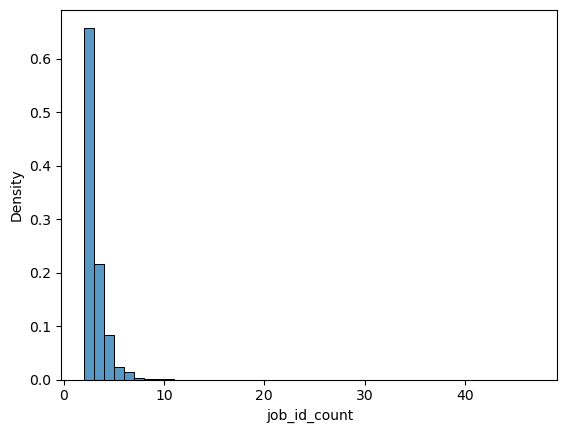

In [18]:
# histogram count of duplicate notes
sns.histplot(data=dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1 ], x="job_id_count", stat='density', binwidth=1);

In [19]:
# dates of duplicates
# takeaway: there are duplicate notes pre spike period
visitDateDuplicates = mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isin( jobIdWDuplicates ), ['visitDate', 'job_id'] ].copy()
visitDateDuplicates['visitDate'] = pd.to_datetime( visitDateDuplicates['visitDate'], utc=True )
visitDateDuplicates.sort_values(by='visitDate', inplace=True)
visitDateDuplicates.head(5)

,visitDate,job_id
1167123,2000-11-02 00:00:00+00:00,4392495/2229719
416845,2004-02-28 00:00:00+00:00,2891778/923165
1119112,2006-03-28 00:00:00+00:00,2168344/494539
1119115,2006-03-28 00:00:00+00:00,2168344/494539
300174,2006-03-28 00:00:00+00:00,2168405/494608


In [20]:
# how many job_id's have different dates?
# date here is EPR date corrected by date dictated. this is not the date from the note
dateCount_perID = visitDateDuplicates.groupby(['job_id'])['visitDate'].unique().reset_index(name="unique_dates")
dateCount_perID['n_dates'] = dateCount_perID['unique_dates'].apply( lambda x: len(x) )
dateCount_perID.sort_values(by='n_dates', ascending=False, inplace=True)
dateCount_perID.head(10)

,job_id,unique_dates,n_dates
42594,4168628,"[2020-07-07 00:00:00+00:00, 2020-07-30 00:00:0...",3
31068,3568817,"[2019-06-25 00:00:00+00:00, 2019-06-26 00:00:0...",2
18774,3097983/1070316,"[2008-09-01 00:00:00+00:00, 2008-09-16 00:00:0...",2
59391,4430694,"[2020-12-03 00:00:00+00:00, 2020-12-04 00:00:0...",2
9172,2890728,"[2018-05-15 00:00:00+00:00, 2018-05-16 00:00:0...",2
40265,4092925/1604340,"[2015-01-23 00:00:00+00:00, 2015-07-23 00:00:0...",2
247,2208730,"[2017-03-08 00:00:00+00:00, 2017-07-31 00:00:0...",2
34797,3777638/1642679,"[2010-05-25 00:00:00+00:00, 2010-05-27 00:00:0...",2
60389,4446698,"[2020-12-03 00:00:00+00:00, 2020-12-13 00:00:0...",2
32049,3627794/1215635,"[2014-10-29 00:00:00+00:00, 2015-01-28 00:00:0...",2


In [22]:
print( "Number of job id's with multiple dates: ", sum( dateCount_perID['n_dates'] > 1 ) )
print( "Percentage of all job id's: ", sum( dateCount_perID['n_dates'] > 1 ) / dateCount_perID.shape[0] )

Number of job id's with multiple dates:  135
Percentage of all job id's:  0.002052763628069642


In [23]:
job_id_multiple_dates = list( dateCount_perID.loc[ dateCount_perID['n_dates'] > 1 ]['job_id'].unique() )
print( 'Count of records with multiple dates: ', visitDateDuplicates.loc[ visitDateDuplicates['job_id'].isin( job_id_multiple_dates ) ].shape[0] )
print( 'Percentage with respect to all records with duplicity: ', visitDateDuplicates.loc[ visitDateDuplicates['job_id'].isin( job_id_multiple_dates ) ].shape[0] / visitDateDuplicates.shape[0] )

Count of records with multiple dates:  311
Percentage with respect to all records with duplicity:  0.0018641172415859982


In [25]:
visitDateDuplicatesGrp = visitDateDuplicates.groupby(['visitDate']).size().reset_index(name='note_count')
visitDateDuplicatesGrp['cumsum'] = visitDateDuplicatesGrp['note_count'].cumsum()
visitDateDuplicatesGrp['ecdf'] = visitDateDuplicatesGrp['cumsum']/visitDateDuplicatesGrp['note_count'].sum() * pct_duplicates
visitDateDuplicatesGrp

,visitDate,note_count,cumsum,ecdf
0,2000-11-02 00:00:00+00:00,1,1,0.000001
1,2004-02-28 00:00:00+00:00,1,2,0.000002
2,2006-03-28 00:00:00+00:00,8,10,0.000011
3,2006-03-29 00:00:00+00:00,4,14,0.000015
4,2006-03-30 00:00:00+00:00,2,16,0.000017
...,...,...,...,...
2271,2021-01-27 00:00:00+00:00,335,166118,0.174483
2272,2021-01-28 00:00:00+00:00,428,166546,0.174932
2273,2021-01-29 00:00:00+00:00,239,166785,0.175183
2274,2021-01-30 00:00:00+00:00,28,166813,0.175213


/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

Text(0, 0.5, 'cumulative proportion of notes with duplicates')

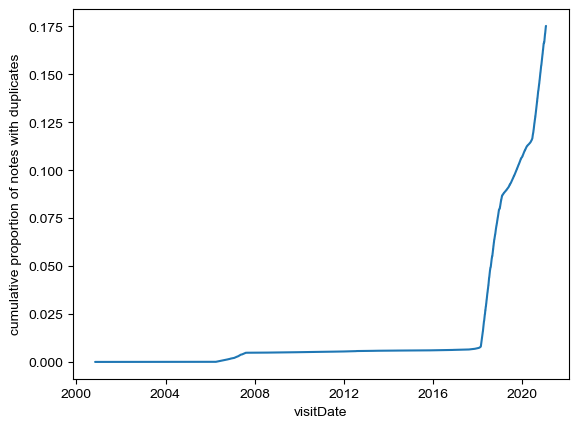

In [26]:
fig, ax = plt.subplots();
sns.set_theme()
sns.set_style("whitegrid")
# need to multiply this by 70%
sns.lineplot(data=visitDateDuplicatesGrp, x="visitDate", y='ecdf', ax=ax);
ax.set_ylabel('cumulative proportion of notes with duplicates')

In [27]:
dfCounts = dfJobIDCount.loc[ dfJobIDCount['job_id'].isin( jobIdWDuplicates ), ['job_id', 'job_id_count'] ].copy()
dfDateThresh = pd.merge( mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isin(jobIdWDuplicates), ['job_id','visitDate'] ], dfCounts , how = 'left', on = 'job_id' )
dfDateThresh['visitDate'] = pd.to_datetime( dfDateThresh['visitDate'], utc=True )
dfDateThresh.sort_values( by = 'visitDate', inplace=True )
dfDateThreshGrp = dfDateThresh.groupby(['visitDate'])['job_id_count'].max().reset_index(name='duplicity')
dfDateThreshGrp['cumulative_duplicity'] = dfDateThreshGrp['duplicity'].cummax()
dfDateThreshGrp['visitDate'] = pd.to_datetime( dfDateThreshGrp['visitDate'], utc=True )
dfDateThreshGrp

,visitDate,duplicity,cumulative_duplicity
0,2000-11-02 00:00:00+00:00,2,2
1,2004-02-28 00:00:00+00:00,2,2
2,2006-03-28 00:00:00+00:00,2,2
3,2006-03-29 00:00:00+00:00,2,2
4,2006-03-30 00:00:00+00:00,2,2
...,...,...,...
2271,2021-01-27 00:00:00+00:00,4,47
2272,2021-01-28 00:00:00+00:00,4,47
2273,2021-01-29 00:00:00+00:00,3,47
2274,2021-01-30 00:00:00+00:00,4,47


/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

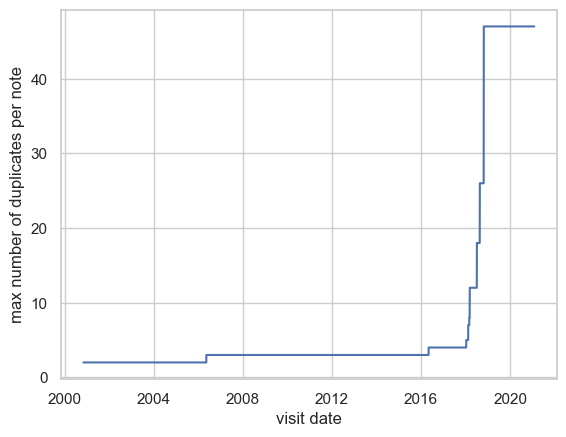

In [28]:
fig, ax = plt.subplots();
sns.set_theme()
sns.set_style("whitegrid")
sns.lineplot(data=dfDateThreshGrp, x="visitDate", y='cumulative_duplicity', ax=ax);
ax.set_ylabel('max number of duplicates per note');
ax.set_xlabel('visit date');

In [29]:
# plot cdf of duplicate notes vs duplicity count
dfDuplicates = dfJobIDCount.loc[ dfJobIDCount['job_id_count'] > 1, ['job_id', 'job_id_count'] ].copy()
dfGrpByCount = dfDuplicates.groupby(['job_id_count'])['job_id'].size().reset_index(name='number_of_jobIDs')
dfGrpByCount.rename( columns={"job_id_count":"duplicity"}, inplace=True )
dfGrpByCount['total_notes_w_duplicity'] = dfGrpByCount['duplicity'] * dfGrpByCount['number_of_jobIDs']
dfGrpByCount.sort_values(by='duplicity', inplace=True)
dfGrpByCount['ecdf'] = ( dfGrpByCount['total_notes_w_duplicity'].cumsum() / dfGrpByCount['total_notes_w_duplicity'].sum() ) * pct_duplicates
dfGrpByCount

,duplicity,number_of_jobIDs,total_notes_w_duplicity,ecdf
0,2,43271,86542,0.090900
1,3,14238,42714,0.135765
2,4,5495,21980,0.158851
3,5,1561,7805,0.167049
4,6,902,5412,0.172734
5,7,170,1190,0.173984
6,8,87,696,0.174715
7,9,14,126,0.174847
8,10,11,110,0.174963
9,11,1,11,0.174974


/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

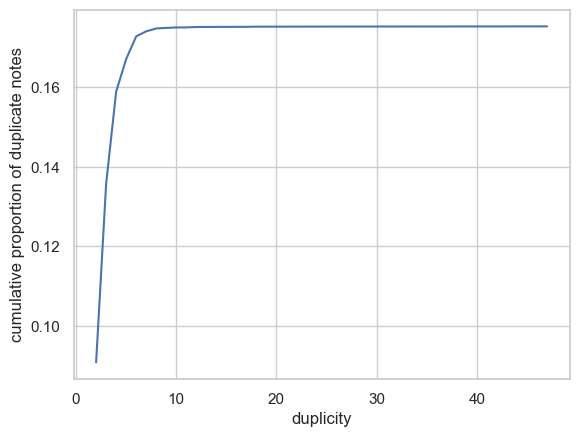

In [30]:
fig, ax = plt.subplots();
sns.set_theme()
sns.set_style("whitegrid")
sns.lineplot(data=dfGrpByCount, x="duplicity", y='ecdf', ax=ax);
ax.set_ylabel('cumulative proportion of duplicate notes');
ax.set_xlabel('duplicity');

# Plot of statistics over selected time frame

In [31]:
# how many notes are between this time period?
startDate='2008-01-01'
endDate='2017-12-31'
maskLowDuplicity=mergedNotesMaster['visitDate'].between( startDate, endDate )
print(f"Proportion of notes between {startDate} and {endDate}: ", sum(maskLowDuplicity)/mergedNotesMaster.shape[0])

Proportion of notes between 2008-01-01 and 2017-12-31:  0.6676057300325674


In [32]:
# how many notes in this period have extractable job id?
nExtractableJob_lowduplicity = mergedNotesMaster.loc[ maskLowDuplicity & mergedNotesMaster['job_id'].notnull() ].shape[0]
print( "Proportion of notes with non-null jobid: ", nExtractableJob_lowduplicity / sum(maskLowDuplicity) )

Proportion of notes with non-null jobid:  0.7536902288675338


In [33]:
# how many notes with extractable job id in this period have duplicates?
pct_duplicates_lowduplicity = mergedNotesMaster.loc[ maskLowDuplicity & mergedNotesMaster['job_id'].isin( jobIdWDuplicates ) ].shape[0] / nExtractableJob_lowduplicity
print( "Proportion of duplicate notes among notes with extractable job id during this period: ",  pct_duplicates_lowduplicity )

Proportion of duplicate notes among notes with extractable job id during this period:  0.003326755259441648


In [34]:
visitDateDuplicates_mask = visitDateDuplicates.loc[ visitDateDuplicates['visitDate'].between(startDate, endDate) ].copy()
visitDateDuplicatesGrp_mask = visitDateDuplicates_mask.groupby(['visitDate']).size().reset_index(name='note_count')
visitDateDuplicatesGrp_mask['cumsum'] = visitDateDuplicatesGrp_mask['note_count'].cumsum()
visitDateDuplicatesGrp_mask['ecdf'] = visitDateDuplicatesGrp_mask['cumsum']/visitDateDuplicatesGrp_mask['note_count'].sum() * pct_duplicates_lowduplicity
visitDateDuplicatesGrp_mask

,visitDate,note_count,cumsum,ecdf
0,2008-01-07 00:00:00+00:00,2,2,0.000003
1,2008-01-17 00:00:00+00:00,2,4,0.000006
2,2008-01-21 00:00:00+00:00,2,6,0.000009
3,2008-02-06 00:00:00+00:00,1,7,0.000011
4,2008-02-07 00:00:00+00:00,1,8,0.000012
...,...,...,...,...
770,2017-12-22 00:00:00+00:00,21,2189,0.003303
771,2017-12-23 00:00:00+00:00,2,2191,0.003306
772,2017-12-24 00:00:00+00:00,3,2194,0.003310
773,2017-12-27 00:00:00+00:00,4,2198,0.003316


/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

Text(0, 0.5, 'cumulative proportion of notes with duplicates')

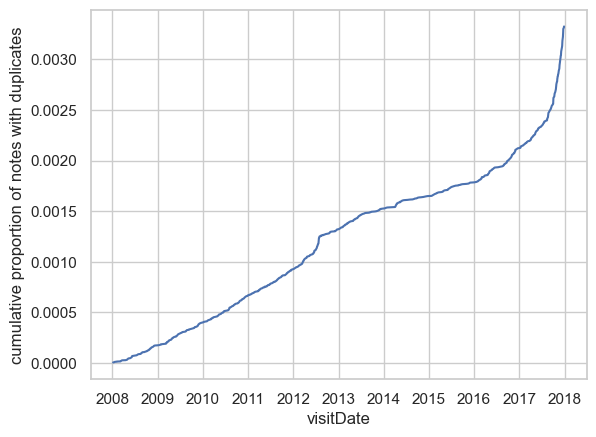

In [35]:
fig, ax = plt.subplots();
sns.set_theme()
sns.set_style("whitegrid")
# need to multiply this by 70%
sns.lineplot(data=visitDateDuplicatesGrp_mask, x="visitDate", y='ecdf', ax=ax);
ax.set_ylabel('cumulative proportion of notes with duplicates')

In [36]:
dfDateThresh_mask = dfDateThresh.loc[ dfDateThresh['visitDate'].between(startDate,endDate) ].copy()
dfDateThreshGrp_mask = dfDateThresh_mask.groupby(['visitDate'])['job_id_count'].max().reset_index(name='duplicity')
dfDateThreshGrp_mask['cumulative_duplicity'] = dfDateThreshGrp_mask['duplicity'].cummax()
dfDateThreshGrp_mask['visitDate'] = pd.to_datetime( dfDateThreshGrp_mask['visitDate'], utc=True )
dfDateThreshGrp_mask

,visitDate,duplicity,cumulative_duplicity
0,2008-01-07 00:00:00+00:00,2,2
1,2008-01-17 00:00:00+00:00,2,2
2,2008-01-21 00:00:00+00:00,2,2
3,2008-02-06 00:00:00+00:00,2,2
4,2008-02-07 00:00:00+00:00,2,2
...,...,...,...
770,2017-12-22 00:00:00+00:00,3,4
771,2017-12-23 00:00:00+00:00,2,4
772,2017-12-24 00:00:00+00:00,2,4
773,2017-12-27 00:00:00+00:00,2,4


/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/wayne/anaconda3/envs/explore/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

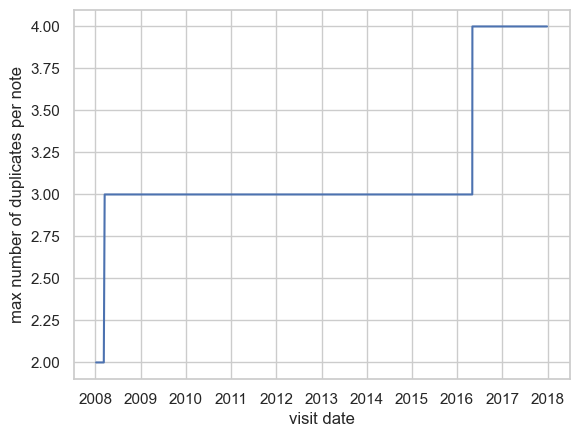

In [37]:
fig, ax = plt.subplots();
sns.set_theme()
sns.set_style("whitegrid")
sns.lineplot(data=dfDateThreshGrp_mask, x="visitDate", y='cumulative_duplicity', ax=ax);
ax.set_ylabel('max number of duplicates per note');
ax.set_xlabel('visit date');

## Investigate status of duplicate notes 

In [38]:
# list of job ids during this low duplicity period with duplicate notes
jobId_0817 = list( mergedNotesMaster.loc[ maskLowDuplicity & mergedNotesMaster['job_id'].isin( jobIdWDuplicates ) ]['job_id'].unique() )
print( len(jobId_0817) )

1032


In [39]:
# extract dataframe for records of job ids during this low duplicity period with duplicate notes
colsToKeep = ['MRN', 'PATIENT_RESEARCH_ID', 'Observations.ProcCode',\
       'Observations.ProcName', 'Observations.Observation._id',\
       'Observations.StatusFromOrder','Observations.Observation.status',\
       'clinical_notes', 'visitDate', 'processed_physician_name', 'job_id', 'lastUpdated' ]
dfDuplicates_0817 = mergedNotesMaster.loc[ mergedNotesMaster['job_id'].isin(jobId_0817), colsToKeep ].copy()
dfDuplicates_0817['status'] = dfDuplicates_0817[['Observations.StatusFromOrder','Observations.Observation.status']].apply(tuple, axis=1)
dfDuplicates_0817.sort_values( by='lastUpdated', ascending=False, inplace=True )

In [40]:
dfDuplicates_0817['lastUpdated']

8363      2021-03-01 20:17:57+00:00
8364      2021-03-01 20:17:35+00:00
502845    2020-10-29 18:23:38+00:00
502846    2020-10-29 18:00:11+00:00
1150379   2020-10-22 13:52:32+00:00
                     ...           
416845    2008-03-10 14:44:28+00:00
199018    2008-02-08 14:49:35+00:00
2758      2008-02-05 23:15:18+00:00
2768      2008-02-04 16:01:19+00:00
792894    2008-02-04 15:28:17+00:00
Name: lastUpdated, Length: 2210, dtype: datetime64[ns, UTC]

In [41]:
# look at the status of these notes with duplicates to see which is the most common status combination
dfStatus_0817 = dfDuplicates_0817.groupby(['status']).size().reset_index(name='counts')
dfStatus_0817['count_pct'] = dfStatus_0817['counts']/dfStatus_0817['counts'].sum()
dfStatus_0817.sort_values( by='count_pct', ascending=False, inplace=True )
dfStatus_0817 

,status,counts,count_pct
1,"(completed, dummy)",1307,0.591403
2,"(completed, final)",260,0.117647
8,"(unknown, dummy)",245,0.110860
7,"(dummy, unknown)",158,0.071493
4,"(completed, unknown)",142,0.064253
0,"(completed, corrected)",65,0.029412
9,"(unknown, unknown)",22,0.009955
6,"(draft, preliminary)",9,0.004072
3,"(completed, preliminary)",1,0.000452
5,"(draft, dummy)",1,0.000452


In [37]:
# randomly sample a few job id's and check if the record with the most recent lastUpdated should be the master
saveDir='/Users/wayne/Desktop/Cluster/ClusterHome/Projects/2023/ClinicalNotes/CheckDuplicates/JobID0817'
random.seed(100)
random_jobid = sample( jobId_0817, 100 )
for job in random_jobid:
    dfTemp = dfDuplicates_0817.loc[ dfDuplicates_0817['job_id'] == job ].copy()
    ptID = dfTemp['PATIENT_RESEARCH_ID'].values[0]
    job_str = job.replace("/","_")
    if not os.path.isdir( f'{saveDir}/{ptID}_{job_str}' ):
        os.mkdir(f'{saveDir}/{ptID}_{job_str}')
    dfTemp.to_csv(f'{saveDir}/{ptID}_{job_str}/record.csv')

In [44]:
print('Number of job ids with last updated on or after 2019: ', sum(dfDuplicates_0817['lastUpdated'].dt.year >= 2019))

Number of job ids with last updated on or after 2019:  92


In [78]:
# randomly sample a few job id's with last updated on or after 2019 to understand why there is a long delay in update
jobId_recentUpdate = list( dfDuplicates_0817.loc[ dfDuplicates_0817['lastUpdated'].dt.year >= 2019 ]['job_id'].unique() )
saveDir='/Users/wayne/Desktop/Cluster/ClusterHome/Projects/2023/ClinicalNotes/CheckDuplicates/JobID0817_recentUpdate'
random.seed(100)
random_jobid = sample( jobId_recentUpdate, 25 )
for job in random_jobid:
    dfTemp = dfDuplicates_0817.loc[ dfDuplicates_0817['job_id'] == job ].copy()
    ptID = dfTemp['PATIENT_RESEARCH_ID'].values[0]
    job_str = job.replace("/","_")
    if not os.path.isdir( f'{saveDir}/{ptID}_{job_str}' ):
        os.mkdir(f'{saveDir}/{ptID}_{job_str}')
    dfTemp.to_csv(f'{saveDir}/{ptID}_{job_str}/record.csv')